## 03. Scratchpad

### 1. File handling via Data.py 

In [1]:
import collections

In [2]:
tab = [1, 2, 1, 3, 1, 1]
for _ in range(len(tab)):
    print('kutas')

kutas
kutas
kutas
kutas
kutas
kutas


In [4]:
import re

In [9]:
tab = [1, 2, 1, 3, 1, 1]
for _ in range(len(tab)):
    print('kutas')
test = 'ksdafasdfutas'
bool(re.search(r"^[k].*", test))

kutas
kutas
kutas
kutas
kutas
kutas


True

In [1]:
import Data
import matplotlib.pyplot as plt

In [2]:
path = '../data/tatoeba_1/eng-pol_1.tsv'
df = Data.upload_tsv(path=path, col_drop=[0, 2])
df.head(3)

,eng_text,pol_text
0,Let's try something.,Spróbujmy coś.
1,I have to go to sleep.,Muszę iść spać.
2,Muiriel is 20 now.,Muiriel ma teraz 20 lat.


In [3]:
df_tok = Data.tokenize_data(df=df, src_col='eng_text', tgt_col='pol_text')
df_tok.head(3)

,eng_text,pol_text,eng_len,pol_len
0,"[lets, try, something, ., <eos>]","[<bos>, spróbujmy, coś, ., <eos>]",5,5
1,"[i, have, to, go, to, sleep, ., <eos>]","[<bos>, muszę, iść, spać, ., <eos>]",8,6
2,"[muiriel, is, 20, now, ., <eos>]","[<bos>, muiriel, ma, teraz, 20, lat, ., <eos>]",6,8


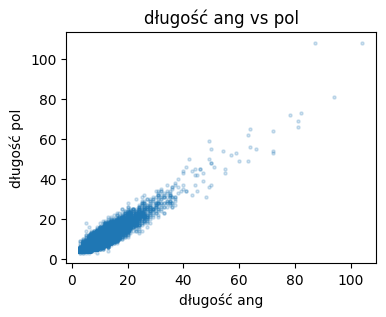

In [4]:
plt.figure(figsize=(4, 3))
plt.scatter(df_tok['eng_len'], df_tok['pol_len'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

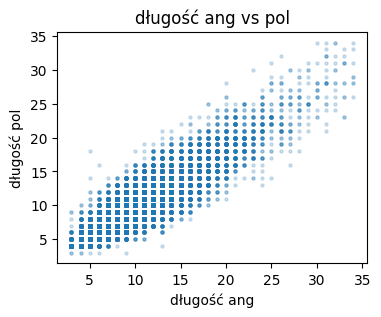

In [5]:
df_trim = Data.trim_data(df=df_tok, src_len='eng_len', tgt_len='pol_len', thres=34)
plt.figure(figsize=(4, 3))
plt.scatter(df_trim['eng_len'], df_trim['pol_len'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

In [6]:
df_ids, eng_vocab, pol_vocab = Data.tokens_to_id(df=df_trim, src_col='eng_text', tgt_col='pol_text')
df_ids.head(3)

,eng_text,pol_text,eng_len,pol_len,src_ids,tgt_ids
0,"[lets, try, something, ., <eos>]","[<bos>, spróbujmy, coś, ., <eos>]",5,5,"[157, 271, 122, 3, 2]","[3, 3407, 68, 4, 2]"
1,"[i, have, to, go, to, sleep, ., <eos>]","[<bos>, muszę, iść, spać, ., <eos>]",8,6,"[5, 20, 6, 54, 6, 329, 3, 2]","[3, 89, 103, 293, 4, 2]"
2,"[muiriel, is, 20, now, ., <eos>]","[<bos>, muiriel, ma, teraz, 20, lat, ., <eos>]",6,8,"[3447, 11, 1744, 94, 3, 2]","[3, 4377, 26, 75, 1344, 115, 4, 2]"


In [7]:
df_data = df_ids[['src_ids', 'tgt_ids']]
df_data.head(3)

,src_ids,tgt_ids
0,"[157, 271, 122, 3, 2]","[3, 3407, 68, 4, 2]"
1,"[5, 20, 6, 54, 6, 329, 3, 2]","[3, 89, 103, 293, 4, 2]"
2,"[3447, 11, 1744, 94, 3, 2]","[3, 4377, 26, 75, 1344, 115, 4, 2]"


In [8]:
df_train, df_val = Data.shuffle_split(df=df_data, tr_per=0.8)
print(df_train.shape, df_val.shape)
df_train.head(3)

(67045, 2) (16762, 2)


,src_ids,tgt_ids
0,"[724, 24, 57, 1381, 57, 553, 3, 2]","[3, 832, 32, 1969, 7424, 20, 1140, 4, 2]"
1,"[98, 44, 5, 186, 363, 10, 2]","[3, 60, 45, 251, 324, 7, 2]"
2,"[150, 8692, 3, 2]","[3, 9, 10, 9101, 17196, 4, 2]"


In [9]:
train_data = Data.EngPolDataset(df_train, 'src_ids', 'tgt_ids')
val_data = Data.EngPolDataset(df_val, 'src_ids', 'tgt_ids')

### 2. Training Transformers Model

In [11]:
import Model
import Trainer

In [12]:
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 512, 4

encoder = Model.TransformerEncoder(len(eng_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
decoder = Model.TransformerDecoder(len(pol_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
model = Model.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.001, pad_id=0, device='cuda')

In [13]:
trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("Test 1")

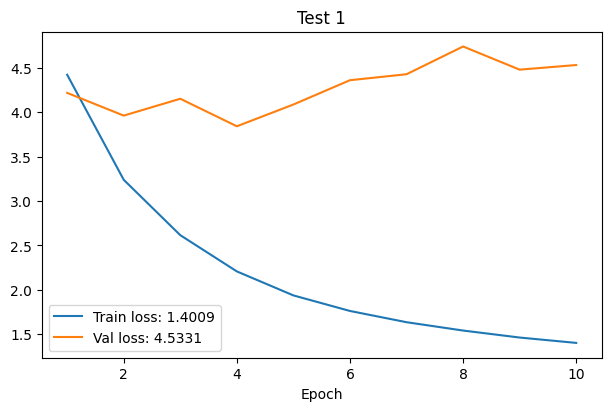

In [14]:
trainer.fit(model, train_data, val_data, 10, '../checkpoints/checkpoint.pt')

### 3. Prediction

In [15]:
import Predict

In [16]:
pol_vocab_rev = {v: k for k, v in pol_vocab.items()}

In [20]:
def translate(snt):
    return Predict.predict_step(snt, eng_vocab, pol_vocab, pol_vocab_rev, model)

In [23]:
tab_lvl1 = ["How are you?", "What are you doing?", "I am a boy.", "He is a boy."]
for snt in tab_lvl1:
    print(translate(snt))

['<bos>', 'jak', 'się', 'czujesz', '?', '<eos>']
['<bos>', 'co', 'robisz', '?', '<eos>']
['<bos>', 'jestem', 'chłopakiem', '.', '<eos>']
['<bos>', 'on', 'jest', 'chłopak', '.', '<eos>']


In [28]:
tab_lvl2 = ["He will be eating dinner.", "I used to play football.", "Thank you so much, that really means a lot."]
for snt in tab_lvl2:
    print(translate(snt))

['<bos>', 'on', 'będzie', 'jeść', 'obiad', '.', '<eos>']
['<bos>', 'zwykłem', 'grać', 'w', 'piłkę', 'nożną', '.', '<eos>']
['<bos>', 'bardzo', 'dziękuję', ',', 'to', 'bardzo', 'dziękuję', '.', '<eos>']
